# **Import req libs**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
#from sklearn.metrics import plot_confusion_matrix

In [ ]:
df = pd.read_csv('processed.cleveland.data', header=None)

In [ ]:
df.head(5)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [ ]:
df.columns = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "hd"
]
df.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,hd
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


# **Identifying missing data**

In [ ]:
df.dtypes

,0
age,float64
sex,float64
cp,float64
trestbps,float64
chol,float64
fbs,float64
restecg,float64
thalach,float64
exang,float64
oldpeak,float64


In [ ]:
df['ca'].unique()

array(['0.0', '3.0', '2.0', '1.0', '?'], dtype=object)

In [ ]:
df['thal'].unique()

array(['6.0', '3.0', '7.0', '?'], dtype=object)

In [ ]:
len(df.loc[(df['ca']=='?')|(df['thal']=='?')])

6

In [ ]:
df.loc[(df['ca']=='?')|(df['thal']=='?')]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,hd
87,53.0,0.0,3.0,128.0,216.0,0.0,2.0,115.0,0.0,0.0,1.0,0.0,?,0
166,52.0,1.0,3.0,138.0,223.0,0.0,0.0,169.0,0.0,0.0,1.0,?,3.0,0
192,43.0,1.0,4.0,132.0,247.0,1.0,2.0,143.0,1.0,0.1,2.0,?,7.0,1
266,52.0,1.0,4.0,128.0,204.0,1.0,0.0,156.0,1.0,1.0,2.0,0.0,?,2
287,58.0,1.0,2.0,125.0,220.0,0.0,0.0,144.0,0.0,0.4,2.0,?,7.0,0
302,38.0,1.0,3.0,138.0,175.0,0.0,0.0,173.0,0.0,0.0,1.0,?,3.0,0


In [ ]:
len(df)

303

In [ ]:
df_no_missing = df.loc[
    (df['ca']!='?')
    &
    (df['thal']!='?')
]

In [ ]:
len(df_no_missing)

297

In [ ]:
df_no_missing['ca'].unique()

array(['0.0', '3.0', '2.0', '1.0'], dtype=object)

In [ ]:
df_no_missing['thal'].unique()

array(['6.0', '3.0', '7.0'], dtype=object)

In [ ]:
df_no_missing_copy = df_no_missing.copy()

In [ ]:
X = df_no_missing_copy.drop('hd', axis=1)
X.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0


In [ ]:
y = df_no_missing_copy['hd']
y.head(5)

,hd
0,0
1,2
2,1
3,0
4,0


In [ ]:
X.dtypes

,0
age,float64
sex,float64
cp,float64
trestbps,float64
chol,float64
fbs,float64
restecg,float64
thalach,float64
exang,float64
oldpeak,float64


In [ ]:
for col in X.columns:
  print(col)
  print(X[col].unique())

age
[63. 67. 37. 41. 56. 62. 57. 53. 44. 52. 48. 54. 49. 64. 58. 60. 50. 66.
 43. 40. 69. 59. 42. 55. 61. 65. 71. 51. 46. 45. 39. 68. 47. 34. 35. 29.
 70. 77. 38. 74. 76.]
sex
[1. 0.]
cp
[1. 4. 3. 2.]
trestbps
[145. 160. 120. 130. 140. 172. 150. 110. 132. 117. 135. 112. 105. 124.
 125. 142. 128. 170. 155. 104. 180. 138. 108. 134. 122. 115. 118. 100.
 200.  94. 165. 102. 152. 101. 126. 174. 148. 178. 158. 192. 129. 144.
 123. 136. 146. 106. 156. 154. 114. 164.]
chol
[233. 286. 229. 250. 204. 236. 268. 354. 254. 203. 192. 294. 256. 263.
 199. 168. 239. 275. 266. 211. 283. 284. 224. 206. 219. 340. 226. 247.
 167. 230. 335. 234. 177. 276. 353. 243. 225. 302. 212. 330. 175. 417.
 197. 198. 290. 253. 172. 273. 213. 305. 216. 304. 188. 282. 185. 232.
 326. 231. 269. 267. 248. 360. 258. 308. 245. 270. 208. 264. 321. 274.
 325. 235. 257. 164. 141. 252. 255. 201. 222. 260. 182. 303. 265. 309.
 307. 249. 186. 341. 183. 407. 217. 288. 220. 209. 227. 261. 174. 281.
 221. 205. 240. 289. 318. 298. 56

# **One Hot Encoding**

In [ ]:
X_encoded = pd.get_dummies(X, columns=['ca', 'thal', 'cp', 'restecg', 'slope'], dtype=int)

In [ ]:
X_encoded.head(5)

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca_0.0,ca_1.0,...,cp_1.0,cp_2.0,cp_3.0,cp_4.0,restecg_0.0,restecg_1.0,restecg_2.0,slope_1.0,slope_2.0,slope_3.0
0,63.0,1.0,145.0,233.0,1.0,150.0,0.0,2.3,1,0,...,1,0,0,0,0,0,1,0,0,1
1,67.0,1.0,160.0,286.0,0.0,108.0,1.0,1.5,0,0,...,0,0,0,1,0,0,1,0,1,0
2,67.0,1.0,120.0,229.0,0.0,129.0,1.0,2.6,0,0,...,0,0,0,1,0,0,1,0,1,0
3,37.0,1.0,130.0,250.0,0.0,187.0,0.0,3.5,1,0,...,0,0,1,0,1,0,0,0,0,1
4,41.0,0.0,130.0,204.0,0.0,172.0,0.0,1.4,1,0,...,0,1,0,0,0,0,1,1,0,0


In [ ]:
y.unique()

array([0, 2, 1, 3, 4])

In [ ]:
y_not_zero_index = y>0
y[y_not_zero_index] = 1
y.unique()

/tmp/ipykernel_1774/2370168997.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y[y_not_zero_index] = 1


array([0, 1])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, random_state=42)

clf_dt = DecisionTreeClassifier(random_state=42)
clf_dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

[Text(0.5169491525423728, 0.9583333333333334, 'ca_0.0 <= 0.5\ngini = 0.498\nsamples = 222\nvalue = [118, 104]\nclass = No HD'),
 Text(0.2584745762711864, 0.875, 'cp_4.0 <= 0.5\ngini = 0.346\nsamples = 90\nvalue = [20, 70]\nclass = Yes HD'),
 Text(0.3877118644067796, 0.9166666666666667, 'True  '),
 Text(0.16101694915254236, 0.7916666666666666, 'oldpeak <= 0.55\ngini = 0.499\nsamples = 31\nvalue = [16, 15]\nclass = No HD'),
 Text(0.0847457627118644, 0.7083333333333334, 'cp_2.0 <= 0.5\ngini = 0.401\nsamples = 18\nvalue = [13, 5]\nclass = No HD'),
 Text(0.03389830508474576, 0.625, 'oldpeak <= 0.35\ngini = 0.165\nsamples = 11\nvalue = [10, 1]\nclass = No HD'),
 Text(0.01694915254237288, 0.5416666666666666, 'gini = 0.0\nsamples = 9\nvalue = [9, 0]\nclass = No HD'),
 Text(0.05084745762711865, 0.5416666666666666, 'trestbps <= 126.5\ngini = 0.5\nsamples = 2\nvalue = [1, 1]\nclass = No HD'),
 Text(0.03389830508474576, 0.4583333333333333, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]\nclass = No HD'),

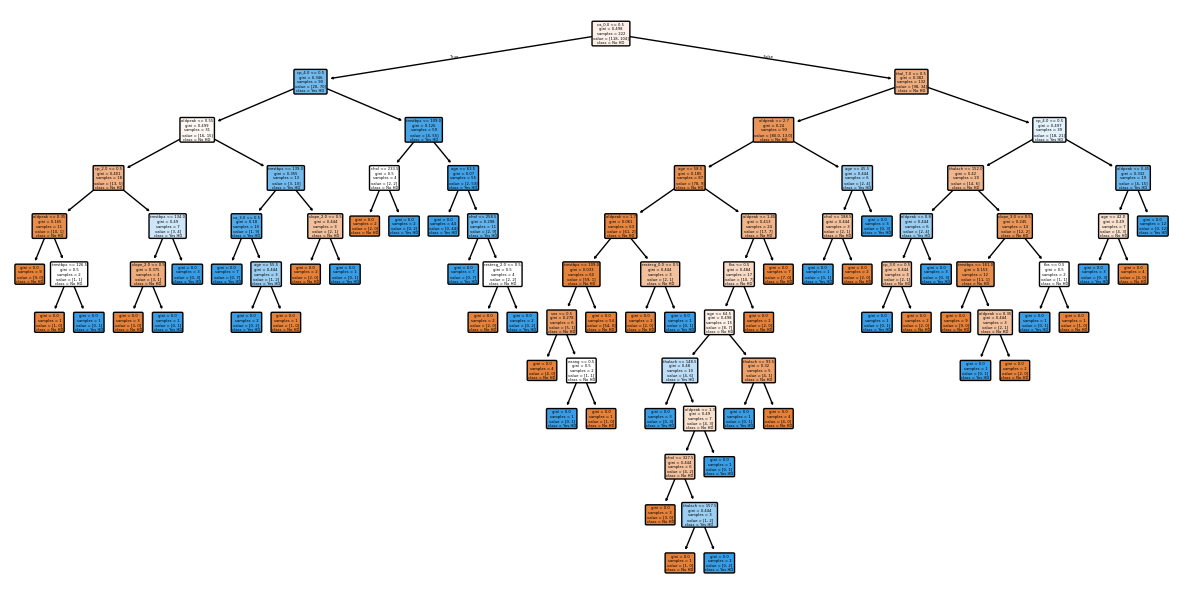

In [ ]:
plt.figure(figsize=(15,7.5))

plot_tree(clf_dt,
          filled=True,
          rounded=True,
          class_names=["No HD", "Yes HD"],
          feature_names=X_encoded.columns

)

This is very deep tree.

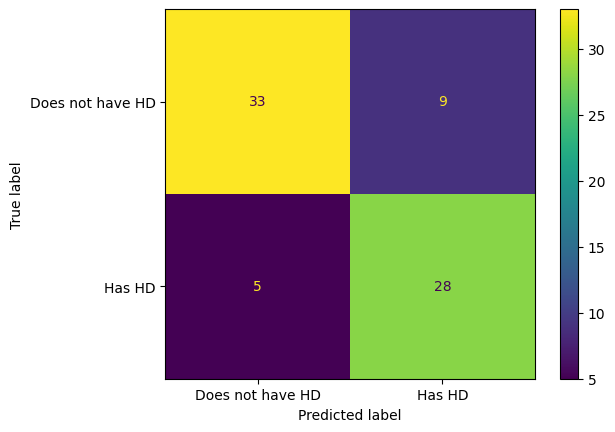

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(clf_dt, X_test, y_test, display_labels=["Does not have HD", "Has HD"])

# **Cost Complexity Pruning**

1. Decision Trees are notorious for being overfit to the Training data.
2. There are a lot of paramaters like max_depth, min_samples that are designed to reduce overfitting.
3. Pruning a tree with cost complexity pruning can simplify the whole process of finding a smaller tree that improves accuracy with Testing Dataset.



Cost-complexity pruning adds a penalty for having a large tree.

Cost = Prediction Error + alpha*complexity

In [ ]:
path = clf_dt.cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = path.ccp_alphas
ccp_alphas = ccp_alphas[:-1]

clf_dts = []

for ccp_alpha in ccp_alphas:
  clf_dt = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
  clf_dt.fit(X_train, y_train)
  clf_dts.append(clf_dt)

In [ ]:
train_scores = [clf_dt.score(X_train, y_train) for clf_dt in clf_dts]
test_scores = [clf_dt.score(X_test, y_test) for clf_dt in clf_dts]

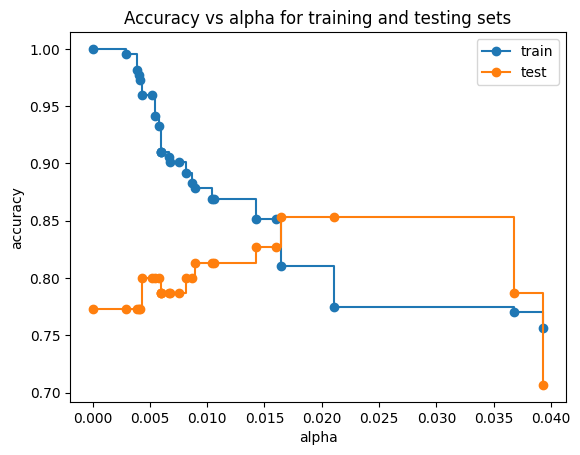

In [ ]:
fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker='o', label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker='o', label="test", drawstyle="steps-post")
ax.legend()
plt.show()

# **Cross Validation**

In [30]:
clf_dt = DecisionTreeClassifier(random_state=42, ccp_alpha=0.016)

<Axes: xlabel='tree'>

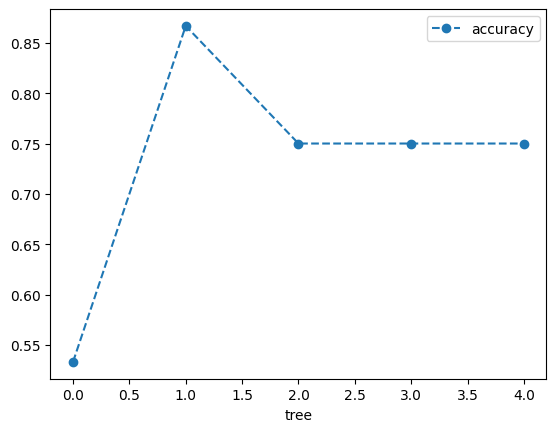

In [31]:
scores = cross_val_score(clf_dt, X_train, y_train, cv = 5)
df = pd.DataFrame(data={'tree': range(5), 'accuracy': scores})

df.plot(x='tree', y='accuracy', marker='o', linestyle='--')

<Axes: xlabel='alpha'>

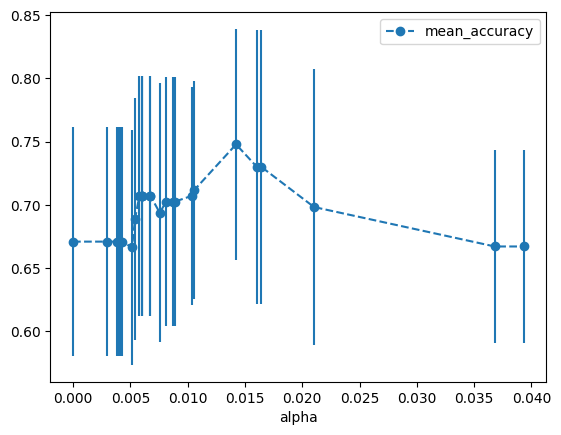

In [32]:
alpha_loop_values = []

for ccp_alpha in ccp_alphas:
  clf_dt = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
  scores = cross_val_score(clf_dt, X_train, y_train, cv=5)
  alpha_loop_values.append([ccp_alpha, np.mean(scores), np.std(scores)])


alpha_results = pd.DataFrame(alpha_loop_values, columns=['alpha', 'mean_accuracy', 'std'])

alpha_results.plot(
    x = 'alpha',
    y = 'mean_accuracy',
    yerr = 'std',
    marker = 'o',
    linestyle = '--'
)

In [33]:
alpha_results[(alpha_results['alpha']>0.014)
               &
              (alpha_results['alpha']<0.015)
]

,alpha,mean_accuracy,std
20,0.014225,0.747778,0.091395


In [34]:
ideal_alpha = alpha_results[(alpha_results['alpha']>0.014)
               &
              (alpha_results['alpha']<0.015)
]['alpha']

In [35]:
ideal_alpha

,alpha
20,0.014225


In [36]:
ideal_alpha = float(ideal_alpha)
ideal_alpha

/tmp/ipykernel_1774/3298109534.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ideal_alpha = float(ideal_alpha)


0.014224751066856332

# **Building, Evaluating, Drawing & Interpreting the Final Classification Tree**

In [38]:
clf_dt_pruned = DecisionTreeClassifier(
    random_state = 42,
    ccp_alpha = ideal_alpha
)

clf_dt_pruned = clf_dt_pruned.fit(X_train, y_train)

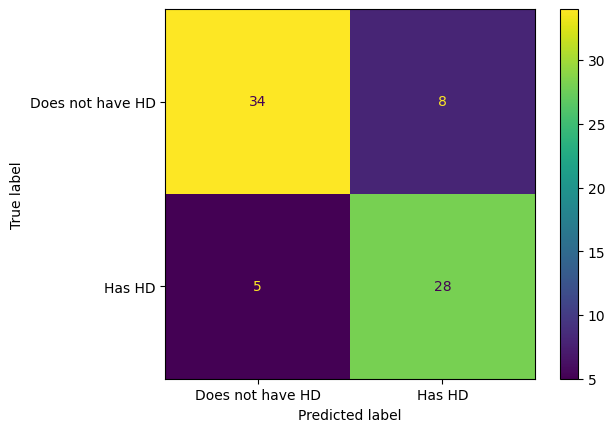

In [39]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(clf_dt_pruned, X_test, y_test, display_labels=["Does not have HD", "Has HD"])

[Text(0.4583333333333333, 0.875, 'ca_0.0 <= 0.5\ngini = 0.498\nsamples = 222\nvalue = [118, 104]\nclass = No HD'),
 Text(0.25, 0.625, 'cp_4.0 <= 0.5\ngini = 0.346\nsamples = 90\nvalue = [20, 70]\nclass = Yes HD'),
 Text(0.35416666666666663, 0.75, 'True  '),
 Text(0.16666666666666666, 0.375, 'oldpeak <= 0.55\ngini = 0.499\nsamples = 31\nvalue = [16, 15]\nclass = No HD'),
 Text(0.08333333333333333, 0.125, 'gini = 0.401\nsamples = 18\nvalue = [13, 5]\nclass = No HD'),
 Text(0.25, 0.125, 'gini = 0.355\nsamples = 13\nvalue = [3, 10]\nclass = Yes HD'),
 Text(0.3333333333333333, 0.375, 'gini = 0.126\nsamples = 59\nvalue = [4, 55]\nclass = Yes HD'),
 Text(0.6666666666666666, 0.625, 'thal_7.0 <= 0.5\ngini = 0.382\nsamples = 132\nvalue = [98, 34]\nclass = No HD'),
 Text(0.5625, 0.75, '  False'),
 Text(0.5, 0.375, 'oldpeak <= 2.7\ngini = 0.24\nsamples = 93\nvalue = [80.0, 13.0]\nclass = No HD'),
 Text(0.4166666666666667, 0.125, 'gini = 0.185\nsamples = 87\nvalue = [78, 9]\nclass = No HD'),
 Text(

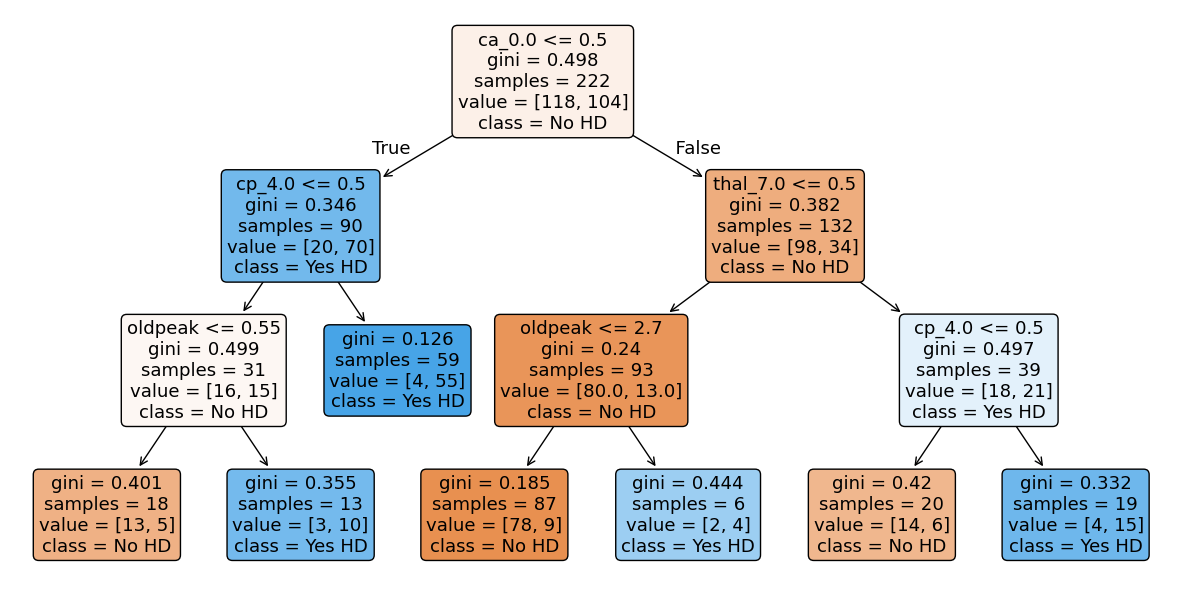

In [40]:
plt.figure(figsize=(15,7.5))

plot_tree(clf_dt_pruned,
          filled=True,
          rounded=True,
          class_names=["No HD", "Yes HD"],
          feature_names=X_encoded.columns

)